<a href="https://colab.research.google.com/github/fox-n/ML_course_homeworks/blob/main/Copy_of_HW_NLP_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).




In [121]:
#install of necessary modules
!pip install opendatasets --upgrade --quiet

In [122]:
import opendatasets as od
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
nltk.download('stopwords')
from nltk.stem.snowball import SnowballStemmer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import time
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.base import clone


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.


In [123]:
dataset_url = 'https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv'
od.download(dataset_url)

raw_df = pd.read_csv('/content/tweet-sentiment-extraction/train.csv')

Skipping, found downloaded files in "./tweet-sentiment-extraction" (use force=True to force download)


In [124]:
raw_df.head(5)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [125]:
raw_df.describe()

,textID,text,selected_text,sentiment
count,27481,27480,27480,27481
unique,27481,27480,22463,3
top,6f7127d9d7,All this flirting going on - The ATG smiles...,good,neutral
freq,1,1,199,11118


In [126]:
raw_df.sentiment.value_counts()

,count
sentiment,
neutral,11118
positive,8582
negative,7781


In [127]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [128]:
#шукаємо рядки з нульовими значеннями
print(raw_df.isnull().sum())

textID           0
text             1
selected_text    1
sentiment        0
dtype: int64


In [129]:
# індекси рядків з нульовими значеннями
null_idx = raw_df.isnull().any(axis=1)
print(raw_df[null_idx])

         textID text selected_text sentiment
314  fdb77c3752  NaN           NaN   neutral


In [130]:
# видаляю рядок з нульовими значеннями і перезаписую датафрейм
raw_df = raw_df.dropna(subset=['text', 'selected_text'])

Висновок: з 27481 рядків, тільки в одному були пропущені значення. Його видалення ніяк не вплине на вирішення задачі

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [131]:
raw_df.sentiment.value_counts(normalize=True)

,proportion
sentiment,
neutral,0.404549
positive,0.312300
negative,0.283151


In [132]:
raw_df['text_len'] = raw_df['text'].str.len()

In [133]:

print(raw_df['text_len'].describe())

count    27480.000000
mean        68.330022
std         35.603870
min          3.000000
25%         39.000000
50%         64.000000
75%         97.000000
max        141.000000
Name: text_len, dtype: float64


In [134]:
(raw_df['text_len']).mode()

,text_len
0,41


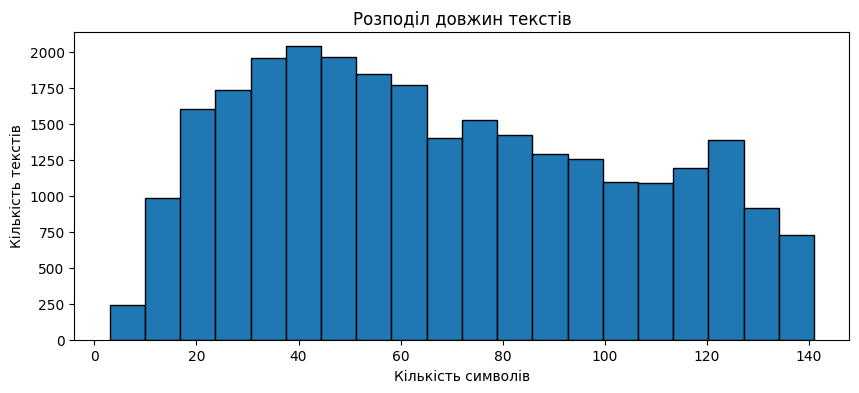

In [135]:
plt.figure(figsize=(10, 4))
plt.hist(raw_df['text_len'], bins=20, edgecolor='black')
plt.title('Розподіл довжин текстів')
plt.xlabel('Кількість символів')
plt.ylabel('Кількість текстів')
plt.show()


### Висновок:
таргет має 3 класи, більшість постів - нейтральні
Тексти мають довжину від 3х до 141 символу. В середньому це - близько 68 символів, найбільш поширене значення - близько 41 символу.
Ймовірно 41 символ - це короткі повідомлення.
141 - це найбільша можлива кіл-ть символів до 2017 року, тобто люди писали по максимуму свої думки.


### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




#### Коментар:
хочу спробувати реалізувати 2ма способами та подивитись як це вплине на модель. Для цього побудую пайплайни

#### Препроцесінг

In [136]:
raw_df

,textID,text,selected_text,sentiment,text_len
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral,36
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative,46
2,088c60f138,my boss is bullying me...,bullying me,negative,25
3,9642c003ef,what interview! leave me alone,leave me alone,negative,31
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative,75
...,...,...,...,...,...
27476,4eac33d1c0,wish we could come see u on Denver husband l...,d lost,negative,77
27477,4f4c4fc327,I`ve wondered about rake to. The client has ...,", don`t force",negative,122
27478,f67aae2310,Yay good for both of you. Enjoy the break - y...,Yay good for both of you.,positive,111
27479,ed167662a5,But it was worth it ****.,But it was worth it ****.,positive,27


In [137]:
#токенізація
raw_df.text.values




array([' I`d have responded, if I were going',
       ' Sooo SAD I will miss you here in San Diego!!!',
       'my boss is bullying me...', ...,
       ' Yay good for both of you. Enjoy the break - you probably need it after such hectic weekend  Take care hun xxxx',
       ' But it was worth it  ****.',
       '   All this flirting going on - The ATG smiles. Yay.  ((hugs))'],
      dtype=object)

In [138]:
raw_vect = CountVectorizer()

In [139]:
raw_vect_fit = raw_vect.fit(raw_df.text)

In [140]:
print(f"Всього унікальних слів: {len(raw_vect.vocabulary_)}")

Всього унікальних слів: 26439


In [141]:
# Підраховуємо частоту кожного слова
word_counts = np.asarray(raw_vect.fit_transform(raw_df.text).sum(axis=0)).flatten()
words = raw_vect.get_feature_names_out()

freq_df = pd.DataFrame({'word': words, 'count': word_counts})
freq_df = freq_df.sort_values('count', ascending=False)

print(f"найчастіші слова:\n {freq_df.head(20)}\n")  # найчастіші слова
print(f"найрідкісніші слова:\n{freq_df.tail(20)}\n")  # найрідкісніші слова

найчастіші слова:
        word  count
23478    to  10032
23138   the   9032
16099    my   5547
12868    it   5406
26209   you   5349
2922    and   5165
12841    is   4009
12491    in   3816
9968    for   3657
16865    of   3155
23124  that   3014
15185    me   2873
17009    on   2871
21463    so   2628
11515  have   2602
5150    but   2408
13333  just   2278
7383    day   2115
25610  with   2098
3956     be   2017

найрідкісніші слова:
               word  count
3              00am      1
2             000th      1
8            02mxjj      1
26416         ½ndel      1
26425     ½sseldorf      1
26423        ½rlich      1
22            07kbq      1
34             0ghz      1
33               0f      1
32           0a7v3j      1
31              0_o      1
30           097dfj      1
28          08kaifj      1
26394  ½anisalovesu      1
26422          ½rio      1
26420        ½rdags      1
26408           ½ll      1
26407            ½l      1
38            0mqko      1
37           0l2tsj 

In [142]:
freq_df_sorted = freq_df.sort_values('count', ascending=False)
total = freq_df_sorted['count'].sum()
freq_df_sorted['cumulative'] = freq_df_sorted['count'].cumsum() / total

# Скільки слів покривають 90% / 95% всіх вживань
for threshold in [0.90, 0.95, 0.99]:
    n = (freq_df_sorted['cumulative'] <= threshold).sum()
    print(f"{threshold:.0%} покриття → {n} слів")

90% покриття → 4164 слів
95% покриття → 10141 слів
99% покриття → 23135 слів


Висновок: можна брати max_features = 5000, це покриє 90% слів

In [143]:
%%time
vectors = raw_vect.transform(raw_df.text)

CPU times: user 635 ms, sys: 1.93 ms, total: 636 ms
Wall time: 800 ms


In [144]:
stemmer = SnowballStemmer(language='english')

In [145]:
def tokenize(text):
    return [stemmer.stem(word) for word in word_tokenize(text)]

In [146]:
english_stopwords = stopwords.words('english')

In [147]:
vectorizer = CountVectorizer(lowercase=True,
                             tokenizer=tokenize,
                             stop_words=english_stopwords,
                             max_features=5000
                             )

In [148]:
%%time
vectorizer.fit(raw_df.text)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


CPU times: user 13.8 s, sys: 32.4 ms, total: 13.8 s
Wall time: 25.4 s


CountVectorizer(max_features=5000,
                stop_words=['a', 'about', 'above', 'after', 'again', 'against',
                            'ain', 'all', 'am', 'an', 'and', 'any', 'are',
                            'aren', "aren't", 'as', 'at', 'be', 'because',
                            'been', 'before', 'being', 'below', 'between',
                            'both', 'but', 'by', 'can', 'couldn', "couldn't", ...],
                tokenizer=<function tokenize at 0x7aea252b09a0>)

In [149]:
%%time
inputs = vectorizer.transform(raw_df.text)

CPU times: user 10.2 s, sys: 8.62 ms, total: 10.2 s
Wall time: 11.7 s


In [150]:
inputs.shape

(27480, 5000)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [151]:
indices = np.arange(inputs.shape[0])

y = raw_df.sentiment
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.3,
    stratify=y,  # зберігаємо розподіл класів
    random_state=42
)
X_train_bow = inputs[train_idx]
X_test_bow = inputs[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

In [152]:
#допоміжна функція для оцінки моделей
def model_estimation(model, inputs, targets):
  model_preds = model.predict(inputs)
  model_accuracy = accuracy_score(targets, model_preds)
  model_f1_score = f1_score(targets, model_preds, average='weighted')

  #print(f"{model}\n")
  #print(f"accuracy_score: {model_accuracy}\n")
  #print(f"f1_score: {model_f1_score}")

  #display(pd.Series(model_preds).value_counts())

  return model_accuracy, model_f1_score

#### Logistic regression

In [153]:
MAX_ITER = 1000
LR_model = LogisticRegression(max_iter=MAX_ITER, solver='sag', class_weight='balanced', C=0.1)

#### Decision Trees model

In [154]:
DT_model = DecisionTreeClassifier(
        max_depth=20,
        min_samples_leaf=20,
        random_state=42)

####XGBoost

In [155]:
XGB_model = XGBClassifier(
        random_state=42,
        n_estimators = 300,
        max_depth = 5,
        learning_rate = 0.01,
        eval_metric='logloss',
        verbosity=0)

In [156]:
# кодування таргету за допомогою LabelEncoder
le = LabelEncoder()

y_train = le.fit_transform(y_train)

y_test = le.transform(y_test)

In [157]:
models_dict = {
    'LogisticRegression' : LR_model,
    'DecisionTree' : DT_model,
    'XGBoost' : XGB_model
      }

In [158]:
#допоміжна функція для порівняння моделей
def models_compare(models_dict, X_train, y_train, X_val, y_val):
  results = []
  for name, model in models_dict.items():
    start = time.time()
    model.fit(X_train, y_train)
    learning_time = time.time() - start
    train_model_accuracy, train_model_f1_score = model_estimation(model, X_train, y_train)
    test_model_accuracy, test_model_f1_score = model_estimation(model, X_val, y_val)

    results.append({
        'Model'         : name,
        'Learning time, s' : learning_time,
        'Accuracy train data' : train_model_accuracy,
        'F1-score train data' : train_model_f1_score,
        'Accuracy test data'  : test_model_accuracy,
        'F1-score test data'  : test_model_f1_score,
        'Difference in F1-score between train and test' : (train_model_f1_score - test_model_f1_score)
          })

  return pd.DataFrame(results)

In [159]:
models_compare(models_dict, X_train_bow, y_train, X_test_bow, y_test)

,Model,"Learning time, s",Accuracy train data,F1-score train data,Accuracy test data,F1-score test data,Difference in F1-score between train and test
0,LogisticRegression,4.466402,0.764868,0.764954,0.690805,0.691282,0.073671
1,DecisionTree,0.340411,0.624610,0.613579,0.618025,0.606902,0.006676
2,XGBoost,13.139406,0.640102,0.629486,0.618025,0.606068,0.023418


In [160]:
#classification report for Logistic regression
y_pred = LR_model.predict(X_test_bow)
print(classification_report(y_test, y_pred, target_names=le.classes_))


              precision    recall  f1-score   support

    negative       0.67      0.68      0.67      2334
     neutral       0.66      0.68      0.67      3335
    positive       0.75      0.72      0.74      2575

    accuracy                           0.69      8244
   macro avg       0.69      0.69      0.69      8244
weighted avg       0.69      0.69      0.69      8244



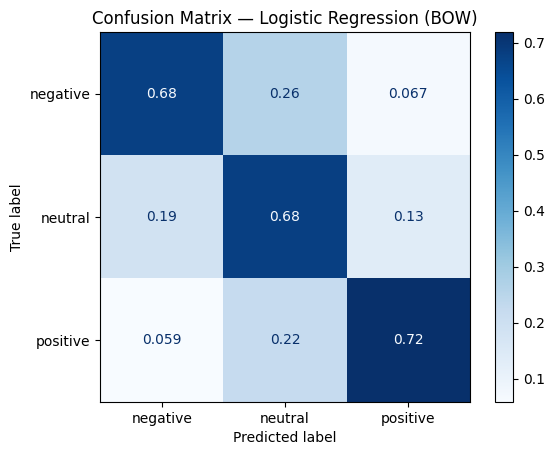

In [161]:
#confusion matrix for Logistic regression
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['negative', 'neutral', 'positive']
)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression (BOW)')
plt.show()

###Висновок:
Без детального тьюнінгу, логістична регресія показала найвищий F1-score, проте саме значення F1-score не дуже високе. З confusion matrix видно, що модель найбільше помиляється передбачаючи негативні коментарі, як нейтральні та нейтральні, як негативні, а також позитивні, як нейтральні та нейтральні, як позитивні.
З classification report видно, що модель трохи краще виявляє позитивні коментарі.

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


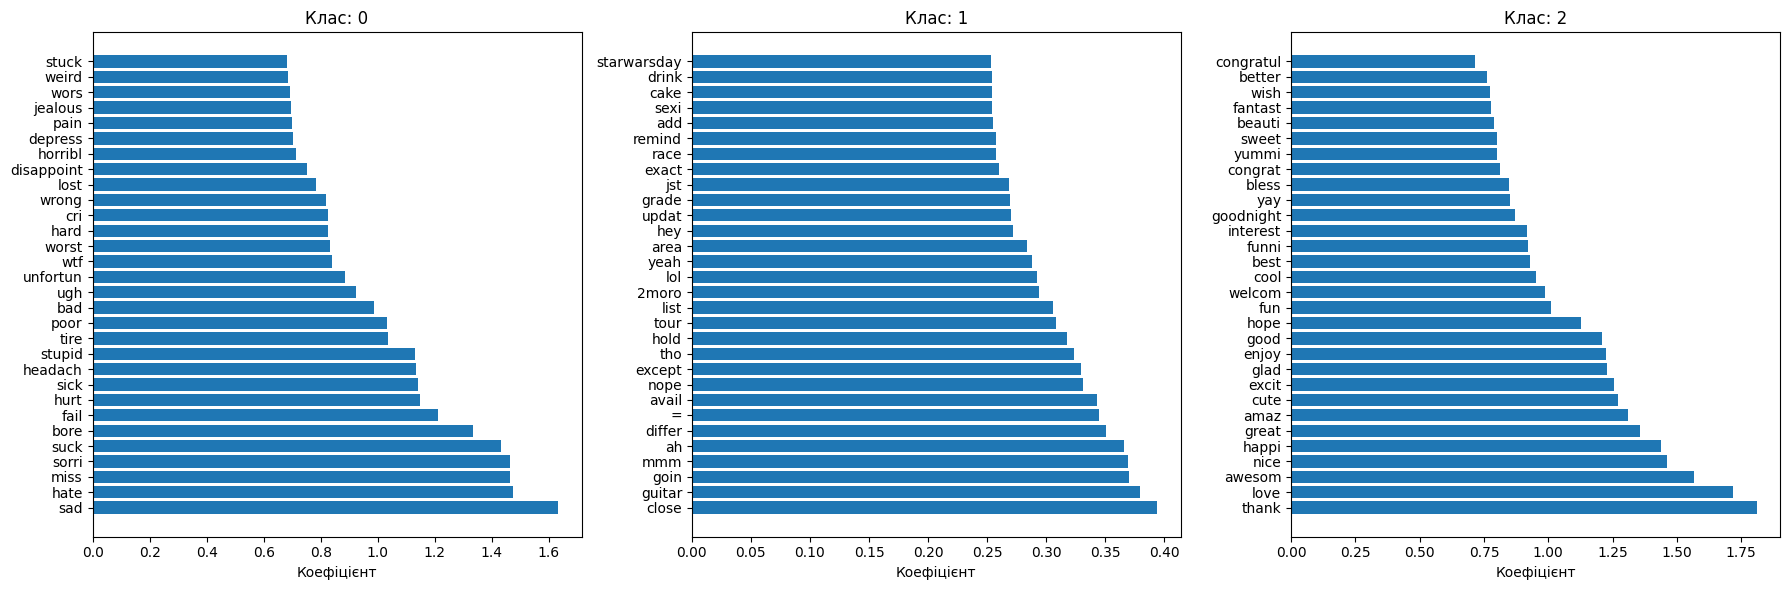

In [162]:
# Отримуємо назви слів зі словника
feature_names = vectorizer.get_feature_names_out()

# Коефіцієнти для кожного класу
classes = LR_model.classes_  # ['negative', 'neutral', 'positive']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (cls, ax) in enumerate(zip(classes, axes)):
    coefs = LR_model.coef_[i]

    # Топ 30 найвпливовіших слів
    top_idx = coefs.argsort()[-30:][::-1]
    top_words = feature_names[top_idx]
    top_coefs = coefs[top_idx]

    ax.barh(top_words, top_coefs)
    ax.set_title(f'Клас: {cls}')
    ax.set_xlabel('Коефіцієнт')

plt.tight_layout()
plt.show()


### Висновок:
Слова, які впливають найбільше на негативний та позитивний клас, здаються підхожими під класи. З нейтральним класом все не так очевидно. Важко сказати чому саме слова "soon, week, friday, last" мають найбільше впливу на нейтральний клас. І чому "=" та "?" відносяться до нейтрального класу, а також "lol".

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [163]:
#допоміжна функція для порівняння векторізацій

def evaluate_vectorizer(vectorizer, model, df, name, test_size=0.3, random_state=42):
    model = clone(model)
    vectorizer = clone(vectorizer)

    # 1. Векторизація всього датасету
    X = vectorizer.fit_transform(df['text'])
    y = le.fit_transform(df['sentiment'])  # le вже визначений

    # 2. Спліт за індексами
    indices = np.arange(X.shape[0])
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, stratify=y, random_state=random_state
    )
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # 3. Навчання
    model.fit(X_train, y_train)

    # 4. Оцінка
    acc_tr, f1_tr = model_estimation(model, X_train, y_train)
    acc_te, f1_te = model_estimation(model, X_test, y_test)

    metrics = {
        'Vectorizer': name,
        'Accuracy train': acc_tr,
        'F1 train': f1_tr,
        'Accuracy test': acc_te,
        'F1 test': f1_te,
        'Overfit (F1 train-test)': f1_tr - f1_te
    }

    artifacts = {
        'model': model,
        'X_test': X_test,
        'y_test': y_test,
        'vectorizer': vectorizer
    }

    return metrics, artifacts

In [164]:
results = []

# BOW
bow_metrics, bow_art = evaluate_vectorizer(
    vectorizer,
    LogisticRegression(max_iter=1000, solver='sag', class_weight='balanced', C=0.1),
    raw_df, name='Bag-of-Words'
)
results.append(bow_metrics)

# TF-IDF
tfidf_metrics, tfidf_art = evaluate_vectorizer(
   # TfidfVectorizer(tokenizer=tokenize,
                    #stop_words=english_stopwords,
                    #max_features=10000, ngram_range=(1, 2),
                    #min_df=2, max_df=0.9, sublinear_tf=True),

    TfidfVectorizer(tokenizer=tokenize,
                    stop_words=english_stopwords, max_features=5000),
    LogisticRegression(max_iter=1000, solver='sag', class_weight='balanced', C=0.1),
    raw_df, name='TF-IDF'
)

results.append(tfidf_metrics)

metrics_comparison = pd.DataFrame(results)
metrics_comparison

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'doe', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated token

,Vectorizer,Accuracy train,F1 train,Accuracy test,F1 test,Overfit (F1 train-test)
0,Bag-of-Words,0.764816,0.764902,0.690805,0.691282,0.073620
1,TF-IDF,0.718029,0.718326,0.666303,0.666905,0.051421


              precision    recall  f1-score   support

    negative       0.65      0.64      0.65      2334
     neutral       0.63      0.67      0.65      3335
    positive       0.73      0.68      0.71      2575

    accuracy                           0.67      8244
   macro avg       0.67      0.67      0.67      8244
weighted avg       0.67      0.67      0.67      8244



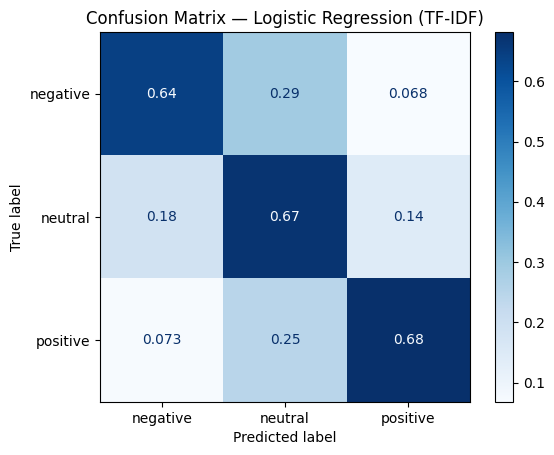

In [165]:
# Дістаємо навчені об'єкти TF-IDF моделі
model = tfidf_art['model']
X_test = tfidf_art['X_test']
y_test = tfidf_art['y_test']
tfidf_vectorizer = tfidf_art['vectorizer']

y_pred = model.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Logistic Regression (TF-IDF)')
plt.show()

In [166]:
#допоміжна функція для витягання топ-токенів

def get_top_tokens(model, vectorizer, class_names, top_n=30):
    feature_names = vectorizer.get_feature_names_out()
    result = {}
    for i, cls in enumerate(class_names):
        coefs = model.coef_[i]
        top_idx = coefs.argsort()[-top_n:][::-1]
        result[cls] = list(feature_names[top_idx])
    return result

In [167]:
bow_tokens = get_top_tokens(bow_art['model'], bow_art['vectorizer'], le.classes_)
tfidf_tokens = get_top_tokens(tfidf_art['model'], tfidf_art['vectorizer'], le.classes_)


In [168]:
# Порівняння поруч для кожного класу
for cls in le.classes_:
    print(f"\n=== {cls.upper()} ===")
    tokens_comparison = pd.DataFrame({
        'BOW': bow_tokens[cls],
        'TF-IDF': tfidf_tokens[cls]
    })
    print(tokens_comparison)


=== NEGATIVE ===
           BOW    TF-IDF
0          sad      miss
1         hate       sad
2         miss     sorri
3        sorri      hate
4         suck      suck
5         bore       bad
6         fail      bore
7         hurt      hurt
8         sick      feel
9      headach      sick
10      stupid      tire
11        tire   headach
12        poor      fail
13         bad       ugh
14         ugh    stupid
15    unfortun      poor
16         wtf       cri
17       worst      lost
18        hard         *
19         cri      hard
20       wrong  unfortun
21        lost       die
22  disappoint      cant
23     horribl     wrong
24     depress      pain
25        pain     worst
26     jealous       wtf
27        wors      kill
28       weird   horribl
29       stuck   depress

=== NEUTRAL ===
            BOW   TF-IDF
0         close        ?
1        guitar      lol
2          goin     yeah
3           mmm    watch
4            ah     home
5        differ       go
6             =

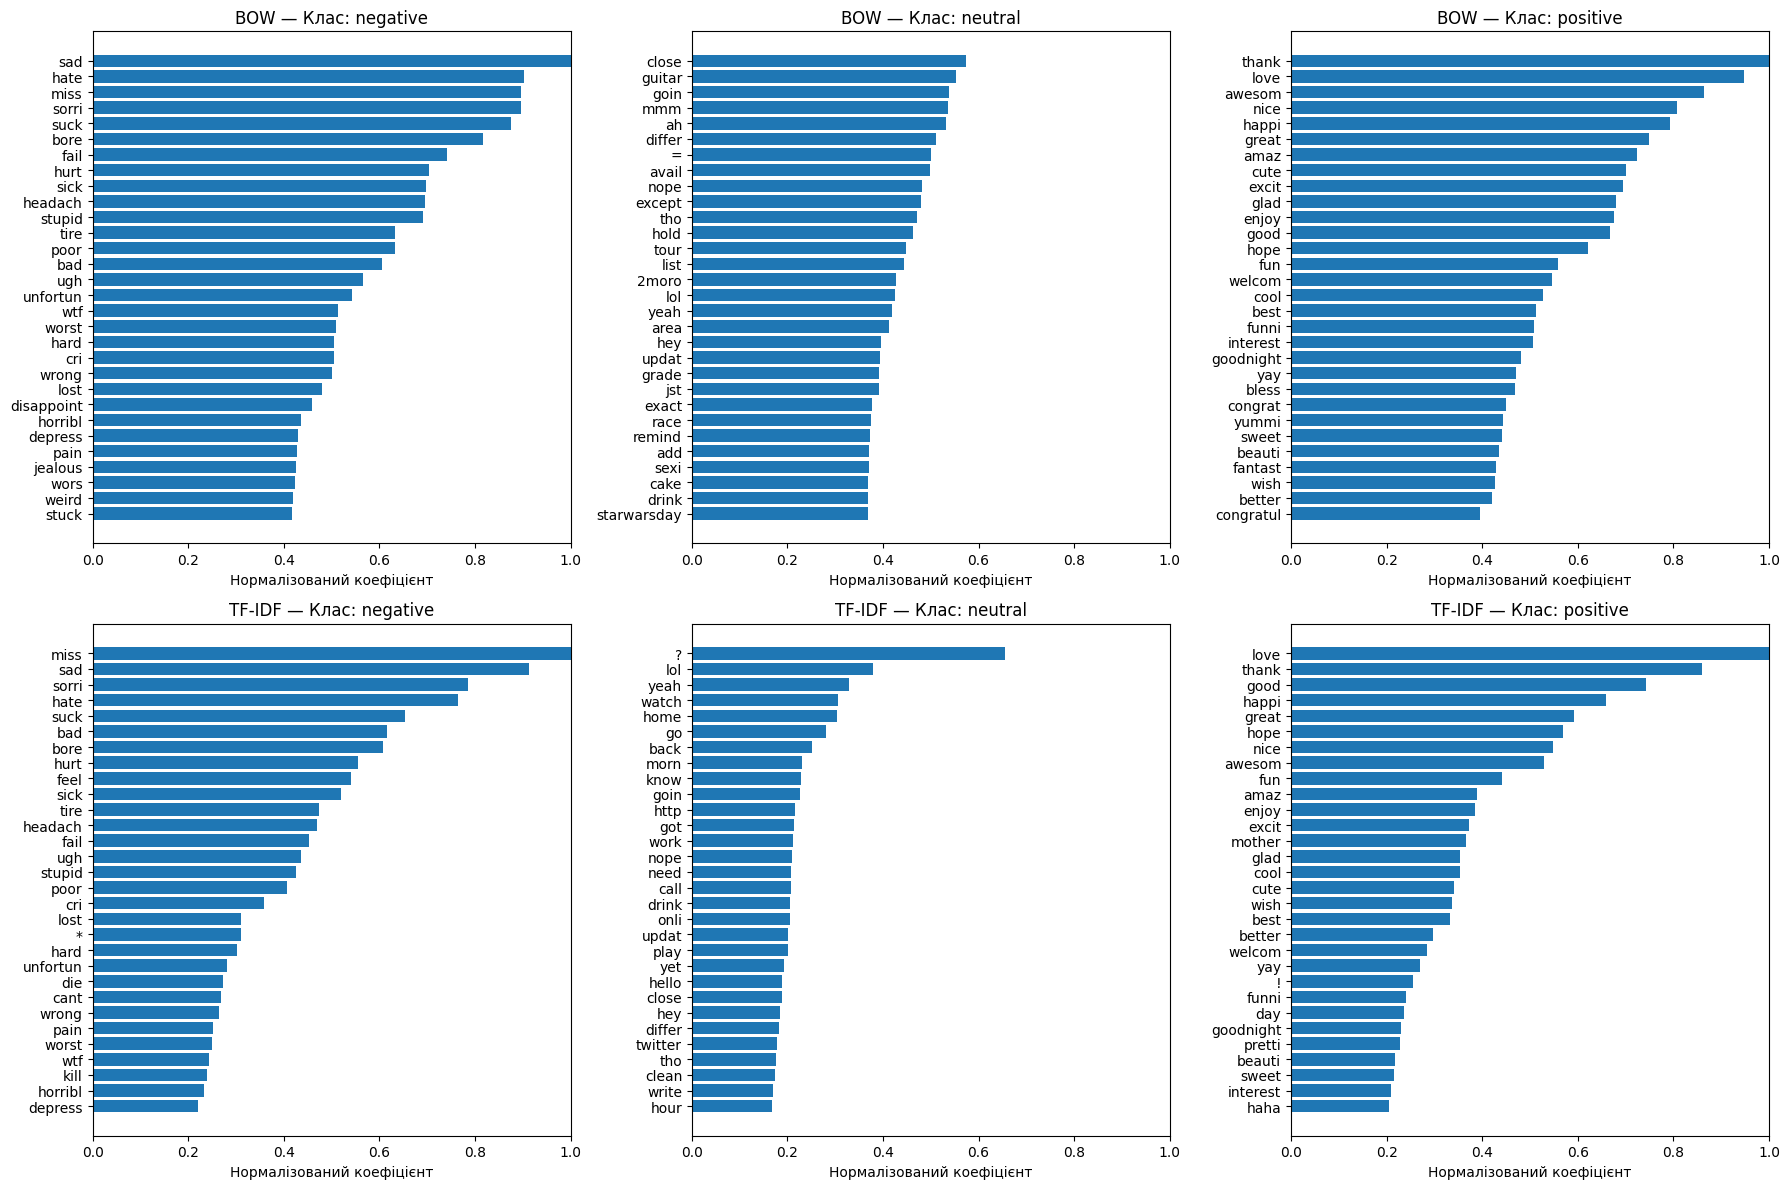

In [169]:
# Порівняння впливу ознак 2 векторайзерів

vectorizers_to_compare = [
    ('BOW', bow_art['model'], bow_art['vectorizer']),
    ('TF-IDF', tfidf_art['model'], tfidf_art['vectorizer'])
]

classes = le.classes_  # ['negative', 'neutral', 'positive']

# Сітка: рядок на векторайзер, стовпець на клас
fig, axes = plt.subplots(len(vectorizers_to_compare), 3, figsize=(18, 12))

for row, (vec_name, model, vec) in enumerate(vectorizers_to_compare):
    feature_names = vec.get_feature_names_out()

    for col, cls in enumerate(classes):
        ax = axes[row, col]
        coefs = model.coef_[col]

        # Топ 30 найвпливовіших слів
        top_idx = coefs.argsort()[-30:][::-1]
        top_words = feature_names[top_idx]
        top_coefs = coefs[top_idx]

        # Нормалізація: ділимо на максимум по модулю в цьому класі
        top_coefs_norm = top_coefs / np.abs(coefs).max()

        ax.barh(top_words, top_coefs_norm)
        ax.set_title(f'{vec_name} — Клас: {cls}')
        ax.set_xlabel('Нормалізований коефіцієнт')
        ax.set_xlim(0, 1)  # однакова шкала для всіх графіків
        ax.invert_yaxis()  # найважливіше слово зверху

plt.tight_layout()
plt.show()

#### Висновок:

При застосуванні класифікатора з TF-IDF векторами, при однаковому препроцесингу та розділенні на трейн і тест, однакових параметрах моделі, якість класифікації вийшла гіршою ніж з BoW векторізацією. Для тестової вибірки f1-score 0.691282 з BoW та 0.666905 з TF-IDF. Розподіл помилок по класах лишився приблизно таким самим. Я пробувала налаштувати параметри TF-IDF, в загальному f1-score трохи покращувався, проте перевершити BoW не зміг. Різниця між f1-score для тренувальної та тестової вибірок на BoW складає 0.073620, а на TF-IDF 0.051421. Тобто модель з TF-IDF показала менший розрив, але так як і на тренувальному наборі вона показала менший fa-score - це скоріше наслідок слабкого навчання ніж кращої генералізациї.

На виявлення негативного класу переважно впливають однакові токени для обох векторизацій, для позитивного вони ще трохи співпадають, але мають різний порядок, для нейтрального токени значно різняться.
Для фінальної імплементації я би вибрала BoW модель, тому що вона простіша і показала кращий f1-score, а переваги TF-IDF в даній задачі не проявляються.

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [170]:
# збираю помилки в датафрейм
# Відновлюємо текст тестових твітів через ті самі test_idx
test_texts = raw_df['text'].iloc[test_idx].reset_index(drop=True)

errors_df = pd.DataFrame({
    'text': test_texts.values,
    'true': le.inverse_transform(y_test),
    'pred': le.inverse_transform(y_pred)
})

# Тільки помилки
errors_df = errors_df[errors_df['true'] != errors_df['pred']]
print(f"Всього помилок: {len(errors_df)} з {len(y_test)}")

Всього помилок: 2751 з 8244


In [171]:
# Які пари true→pred найчастіші
error_pairs = errors_df.groupby(['true', 'pred']).size().sort_values(ascending=False)
print(error_pairs)

true      pred    
negative  neutral     675
positive  neutral     633
neutral   negative    616
          positive    481
positive  negative    187
negative  positive    159
dtype: int64


In [172]:
# Найчастіша помилка — наприклад negative класифіковано як neutral
sample_negative_neutral = errors_df[(errors_df['true']=='negative') & (errors_df['pred']=='neutral')]
for txt in sample_negative_neutral['text'].head(10):
    print(f"• {txt}")

• wearing a pair of trousers that were loose last year, tight this year
•  Oh ok,Thanks.Dont know where the courthouse id either,I`ll learn though.Any nkotb? Twitter stole my pic again  it hates me
• Time to get ready for wrk! Ahhhh, I dnt wanna goooo!
• i have three hours to do my hair. and it STILL won`t be straight
•  I assume you mean 2nd item with 3 nested lines, but no invert call tree button to be found   ï¿½  ï¿½   ï¿½
•  My husband is loosing his GOVERMENT job due to downsizing-he is looking for a new job but can`t find one in our small town
•  Wish I`d had the balls, but with my 2 kids with me and not knowing how illogical these ppl can be, didn`t want to risk it
• Power Outage, door to freezer propped open, 3G ice cream make for slippy floor  M-er F-er!!
•  I would but I`m afraid I got two left feet
•   Getting dizzy. Going to have to lower my original raise. Please don`t think any less of me.


In [173]:
# Найчастіша помилка — наприклад positive класифіковано як neutral
sample_positive_neutral = errors_df[(errors_df['true']=='positive') & (errors_df['pred']=='neutral')]
for txt in sample_positive_neutral['text'].head(10):
    print(f"• {txt}")

• bout tuh head out an find sum wher tuh go an chill
•  you say the nicest things.
•  yeah, it works better as a command
•  read your status update & just wanted 2 b sure I was on your follow list  Hope u r having a wondefl wkend Michael~blessings
• I need a restful weekend, but I will have to work instead
•   really? ur a brave lady walkin around those lions then.  any other book suggestions?
• Back from the gym! I`m no expert or anything, but I`m pretty sure I am not going to be able to move tomorrow, maybe even in a few hours!!
• Everyone`s talking about the goodies at #BEA09.  I wanna be there.
• Getting my hair cut tomorrow or later today I should say...   excited. My swag is already on, jus turning it up!!
•  Journey!? Wow... u just became cooler.  hehe... (is that possible!?)


### Висновок:

Модель найбільше помиляється в реченнях де:

-  багато сленгових скорочень (Hope u r having, sum wher tuh go, dnt wanna)
- де емоція виражається знаками, caps lock'ом або помноженням літер (goooo!,  it STILL won`t, Journey!?)
- де змішані позитивні і негативні сенси (I need a restful weekend, but I will have to work instead)
- або де є фразеологізми (I would but I`m afraid I got two left feet)

Можливі методи покращення:
1. Розширена нормалізація тексту — приведення сленгу і фонетичного написання, обробка подовжених літер і битих символів.
2. Збереження заперечень - не видаляти not/no/n't зі стоп-слів та додати біграми (ngram_range=(1,2)), щоб ловити 'not good', 'can't find' як цілісні ознаки.
3. Контекстні представлення - перейти від BOW/TF-IDF до ембедингів або трансформерів, які враховують значення слів у контексті.

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model